<a href="https://colab.research.google.com/github/PatoTlax/mexico-housing-price-prediction/blob/main/Predicci%C3%B3n_de_vivienda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Instalación**

In [43]:
!pip install -q xgboost shap plotly folium scikit-learn pandas numpy openpyxl
print('✅ Listo')

✅ Listo


# **Imports y configuración**

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)
RANDOM_STATE = 42
print('✅ Imports completados')

✅ Imports completados


# **Carga de datos desde Kaggle**

In [30]:
import os, json
import pandas as pd
import numpy as np

# 1. Credenciales Kaggle
kaggle_token = {
  "username": "TU_USUARIO",
  "key":      "TU_API_KEY"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# 2. Descargar si no existe
if not os.path.exists('/content/data/mexico-city-real-estate-1.csv'):
    os.makedirs('/content/data', exist_ok=True)
    !kaggle datasets download -d allankirwa/mexico-city-real-estate-dataset --unzip -p /content/data/
    print('✅ Dataset descargado')
else:
    print('✅ Dataset ya existe')

# 3. Unir los 5 archivos
archivos = sorted([f for f in os.listdir('/content/data/') if f.endswith('.csv')])
df_original = pd.concat(
    [pd.read_csv(f'/content/data/{f}') for f in archivos],
    ignore_index=True
)
print(f'Total bruto: {df_original.shape[0]:,}')

# 4. Filtrar solo ventas en MXN
df_original = df_original[
    (df_original['operation'] == 'sell') &
    (df_original['currency'] == 'MXN')
].copy()
print(f'Solo ventas MXN: {df_original.shape[0]:,}')

# 5. Separar lat y lon
df_original[['latitud','longitud']] = (df_original['lat-lon']
    .str.split(',', expand=True).astype(float))

# 6. Extraer alcaldía (índice 1)
df_original['ubicacion'] = (df_original['place_with_parent_names']
    .str.split('|').str[1].str.strip().fillna('Desconocido'))

# 7. Superficie: covered primero, si no total
df_original['superficie_m2'] = (df_original['surface_covered_in_m2']
    .fillna(df_original['surface_total_in_m2']))

# 8. Construir df_raw
df_raw = pd.DataFrame({
    'ubicacion':        df_original['ubicacion'],
    'tipo_inmueble':    df_original['property_type'],
    'recamaras':        df_original['rooms'],
    'banos':            np.nan,
    'estacionamientos': np.nan,
    'superficie_m2':    df_original['superficie_m2'],
    'antiguedad':       'Desconocida',
    'latitud':          df_original['latitud'],
    'longitud':         df_original['longitud'],
    'precio_mxn':       df_original['price_aprox_local_currency']
}).reset_index(drop=True)

# 9. Limpieza — sin filtrar recámaras, imputar
df_raw = df_raw.dropna(subset=['precio_mxn','latitud','superficie_m2'])
df_raw = df_raw[df_raw['superficie_m2'] > 0]
df_raw = df_raw[df_raw['precio_mxn'] > 0]

# Imputar recámaras con mediana por tipo de inmueble
df_raw['recamaras'] = df_raw.groupby('tipo_inmueble')['recamaras'].transform(
    lambda x: x.fillna(x.median())
)
# Si aún quedan NaN (tipos con todos nulos) imputar con mediana global
df_raw['recamaras'] = df_raw['recamaras'].fillna(df_raw['recamaras'].median())

# Eliminar outliers extremos de recámaras (>10)
df_raw = df_raw[df_raw['recamaras'] <= 10]

# 10. Eliminar outliers p1-p99 en precio y superficie
q1,  q99 = df_raw['precio_mxn'].quantile([0.01, 0.99])
s1,  s99 = df_raw['superficie_m2'].quantile([0.01, 0.99])
df_raw = df_raw[
    (df_raw['precio_mxn'].between(q1, q99)) &
    (df_raw['superficie_m2'].between(s1, s99))
].reset_index(drop=True)

print(f'\n✅ Dataset final: {df_raw.shape[0]:,} propiedades')
print(f'Ubicaciones únicas: {df_raw.ubicacion.nunique()}')
print(df_raw.ubicacion.value_counts().head(10))
print(f'\nPrecio mínimo:  ${df_raw.precio_mxn.min():,.0f}')
print(f'Precio mediana: ${df_raw.precio_mxn.median():,.0f}')
print(f'Precio máximo:  ${df_raw.precio_mxn.max():,.0f}')
print(f'Superficie mediana: {df_raw.superficie_m2.median():.0f} m²')
print(f'Recámaras con imputación: {(df_raw.recamaras > 0).sum():,}')
df_raw.head()

✅ Dataset ya existe
Total bruto: 23,140
Solo ventas MXN: 19,756

✅ Dataset final: 17,006 propiedades
Ubicaciones únicas: 31
ubicacion
Benito Juárez          4683
Cuauhtémoc             1933
Álvaro Obregón         1851
Miguel Hidalgo         1377
Coyoacán               1126
Tlalpan                 931
Gustavo A. Madero       884
Iztapalapa              812
Azcapotzalco            659
Venustiano Carranza     585
Name: count, dtype: int64

Precio mínimo:  $368,301
Precio mediana: $2,084,744
Precio máximo:  $24,773,843
Superficie mediana: 95 m²
Recámaras con imputación: 17,006


,ubicacion,tipo_inmueble,recamaras,banos,estacionamientos,superficie_m2,antiguedad,latitud,longitud,precio_mxn
0,Miguel Hidalgo,apartment,2.00,NaN,NaN,54.00,Desconocida,23.63,-102.55,"5,450,245.50"
1,Iztapalapa,house,3.00,NaN,NaN,80.00,Desconocida,19.31,-99.07,"1,498,321.97"
2,Tlalpan,apartment,2.00,NaN,NaN,100.00,Desconocida,19.28,-99.23,"918,284.00"
3,Miguel Hidalgo,apartment,2.00,NaN,NaN,135.00,Desconocida,23.63,-102.55,"6,352,013.39"
4,Miguel Hidalgo,apartment,2.00,NaN,NaN,87.00,Desconocida,19.43,-99.18,"4,376,051.62"


In [31]:
# DIAGNÓSTICO DE FILTROS
df_test = pd.DataFrame({
    'ubicacion':     df_original['ubicacion'],
    'tipo_inmueble': df_original['property_type'],
    'recamaras':     df_original['rooms'],
    'superficie_m2': df_original['surface_covered_in_m2'].fillna(df_original['surface_total_in_m2']),
    'latitud':       df_original['latitud'],
    'longitud':      df_original['longitud'],
    'precio_mxn':    df_original['price_aprox_local_currency']
})

total = len(df_test)
con_precio    = df_test['precio_mxn'].notna().sum()
con_lat       = df_test['latitud'].notna().sum()
con_sup       = df_test['superficie_m2'].notna().sum()
con_sup_pos   = (df_test['superficie_m2'] > 0).sum()
con_rec       = df_test['recamaras'].between(1,10).sum()
con_todo      = df_test.dropna(subset=['precio_mxn','latitud','superficie_m2'])
con_todo      = con_todo[con_todo['superficie_m2'] > 0]
con_todo      = con_todo[con_todo['precio_mxn'] > 0]
con_todo_rec  = con_todo[con_todo['recamaras'].between(1,10)]

print(f'Total ventas MXN:          {total:,}')
print(f'Con precio válido:         {con_precio:,}')
print(f'Con latitud:               {con_lat:,}')
print(f'Con superficie:            {con_sup:,}')
print(f'Con superficie > 0:        {con_sup_pos:,}')
print(f'Con recámaras 1-10:        {con_rec:,}')
print(f'Sin filtro recámaras:      {len(con_todo):,}')
print(f'Con filtro recámaras:      {len(con_todo_rec):,}')
print(f'\nDistribución recámaras:')
print(df_test['recamaras'].value_counts().sort_index().head(15))

Total ventas MXN:          19,756
Con precio válido:         19,756
Con latitud:               17,997
Con superficie:            19,586
Con superficie > 0:        19,219
Con recámaras 1-10:        500
Sin filtro recámaras:      17,600
Con filtro recámaras:      319

Distribución recámaras:
recamaras
1.00      29
2.00     255
3.00     136
4.00      42
5.00      16
6.00      14
7.00       2
8.00       4
9.00       1
10.00      1
18.00      1
Name: count, dtype: int64


# **EDA: Distribución de precios + skewness**

In [32]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Precio original','log(precio) — más normal'))
fig.add_trace(go.Histogram(x=df_raw['precio_mxn']/1e6, nbinsx=60,
    marker_color='#3B8BD4', name='Precio'), row=1, col=1)
fig.add_trace(go.Histogram(x=np.log1p(df_raw['precio_mxn']), nbinsx=60,
    marker_color='#1D9E75', name='log(Precio)'), row=1, col=2)
fig.update_layout(title='Distribución de precios de vivienda en México',
    showlegend=False, height=400, template='plotly_white')
fig.update_xaxes(title_text='Millones MXN', row=1, col=1)
fig.update_xaxes(title_text='ln(precio)', row=1, col=2)
fig.show()
print(f'Skewness original: {df_raw.precio_mxn.skew():.2f}  → usaremos log(precio) como target')

Skewness original: 2.63  → usaremos log(precio) como target


# **EDA: Precio mediano por ubicación**

In [33]:
precio_ub = (df_raw.groupby('ubicacion')['precio_mxn']
             .agg(['median','count']).sort_values('median',ascending=False).reset_index())
precio_ub.columns = ['Ubicación','Mediana','N']

fig = px.bar(precio_ub, x='Mediana', y='Ubicación', orientation='h',
    text=precio_ub['Mediana'].apply(lambda x: f'${x/1e6:.1f}M'),
    color='Mediana', color_continuous_scale='Viridis',
    title='Precio mediano por ubicación')
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Precio mediano (MXN)', yaxis_title='',
    coloraxis_showscale=False, template='plotly_white', height=580, margin=dict(l=140))
fig.show()

# **EDA: Scatter precio vs M2**

In [34]:
df_s = df_raw.sample(3000, random_state=42)
fig = px.scatter(df_s, x='superficie_m2', y='precio_mxn',
    color='tipo_inmueble', size='recamaras', opacity=0.6,
    trendline='ols', trendline_scope='overall',
    hover_data=['ubicacion','antiguedad'],
    color_discrete_sequence=px.colors.qualitative.Vivid,
    title='Precio vs Superficie m² — ¿tamaño o ubicación?')
fig.update_layout(xaxis_title='Superficie (m²)', yaxis_title='Precio (MXN)',
    template='plotly_white', height=480,
    yaxis=dict(tickformat='$,.0f'))
fig.show()

# **EDA: Mapa de calor**

In [35]:
mapa = folium.Map(location=[19.4,-99.1], zoom_start=10, tiles='CartoDB positron')

df_geo = df_raw[['latitud','longitud','precio_mxn']].dropna()
max_p  = df_geo['precio_mxn'].max()
heat_data = [[r.latitud, r.longitud, r.precio_mxn/max_p] for r in df_geo.itertuples()]
HeatMap(heat_data, radius=12, blur=8,
    gradient={0.2:'#3B8BD4',0.5:'#F2A623',1.0:'#E85D24'}).add_to(mapa)

# Marcadores por ubicación calculados desde los datos reales
ubicaciones_reales = df_raw.groupby('ubicacion').agg(
    lat=('latitud','mean'),
    lon=('longitud','mean'),
    precio_med=('precio_mxn','median')
).reset_index()

for _, row in ubicaciones_reales.iterrows():
    folium.CircleMarker(
        location=[row.lat, row.lon], radius=8,
        popup=f'<b>{row.ubicacion}</b><br>${row.precio_med/1e6:.1f}M MXN',
        color='white', fill=True, fill_color='#1D9E75',
        fill_opacity=0.8, weight=2).add_to(mapa)

mapa.save('mapa_precios_vivienda.html')
print('✅ mapa_precios_vivienda.html guardado')
mapa

✅ mapa_precios_vivienda.html guardado


# **Limpieza + feature engineering**

In [45]:
df = df_raw.copy()

# Imputar baños ANTES del encoding (tipo_inmueble aún existe)
df['banos'] = df.groupby(['tipo_inmueble','recamaras'])['banos'].transform(
    lambda x: x.fillna(x.median())
)
df['banos'] = df['banos'].fillna((df['recamaras'] * 0.75).round()).clip(lower=1)

# Imputar estacionamientos ANTES del encoding
df['estacionamientos'] = df.groupby(['tipo_inmueble','ubicacion'])['estacionamientos'].transform(
    lambda x: x.fillna(x.median())
)
df['estacionamientos'] = df['estacionamientos'].fillna(
    df['tipo_inmueble'].map({'apartment':1,'house':2,'PH':2,'store':0})
).fillna(1)

print(f'Baños nulos restantes:           {df.banos.isna().sum()}')
print(f'Estacionamientos nulos restantes: {df.estacionamientos.isna().sum()}')

# Eliminar outliers p1-p99
Q1, Q99 = df['precio_mxn'].quantile([0.01, 0.99])
n_antes = len(df)
df = df[(df['precio_mxn'] >= Q1) & (df['precio_mxn'] <= Q99)]
print(f'Outliers eliminados: {n_antes-len(df)}  |  Dataset: {len(df):,} filas')

# Feature engineering
df['ratio_banos_rec']       = df['banos'] / df['recamaras']
df['total_ambientes']       = df['recamaras'] + df['banos'] + df['estacionamientos']
df['m2_por_recamara']       = df['superficie_m2'] / df['recamaras']
df['tiene_estacionamiento'] = (df['estacionamientos'] > 0).astype(int)
df['es_cdmx']               = (df['latitud'].between(19.0,19.6) &
                               df['longitud'].between(-99.4,-98.9)).astype(int)

ant_map = {'Nueva':0,'1-5 años':1,'6-10 años':2,'11-20 años':3,'+20 años':4,'Desconocida':2}
df['antiguedad_ord'] = df['antiguedad'].map(ant_map)

# Encoding
df = pd.get_dummies(df, columns=['tipo_inmueble'], prefix='tipo', drop_first=True)
le = LabelEncoder()
df['ubicacion_enc'] = le.fit_transform(df['ubicacion'])
df['log_precio']    = np.log1p(df['precio_mxn'])

print(f'✅ Features creadas  |  Shape: {df.shape}')
df.head(3)

Baños nulos restantes:           0
Estacionamientos nulos restantes: 0
Outliers eliminados: 340  |  Dataset: 16,666 filas
✅ Features creadas  |  Shape: (16666, 20)


,ubicacion,recamaras,banos,estacionamientos,superficie_m2,antiguedad,latitud,longitud,precio_mxn,ratio_banos_rec,total_ambientes,m2_por_recamara,tiene_estacionamiento,es_cdmx,antiguedad_ord,tipo_apartment,tipo_house,tipo_store,ubicacion_enc,log_precio
0,Miguel Hidalgo,2.00,2.00,1.00,54.00,Desconocida,23.63,-102.55,"5,450,245.50",1.00,5.00,27.00,1,0,2,True,False,False,16,15.51
1,Iztapalapa,3.00,2.00,2.00,80.00,Desconocida,19.31,-99.07,"1,498,321.97",0.67,7.00,26.67,1,1,2,False,True,False,13,14.22
2,Tlalpan,2.00,2.00,1.00,100.00,Desconocida,19.28,-99.23,"918,284.00",1.00,5.00,50.00,1,1,2,True,False,False,23,13.73


# **Split + target encoding**

In [46]:
FEATURES = [
    'superficie_m2','recamaras','banos','estacionamientos',
    'latitud','longitud','antiguedad_ord','ubicacion_enc',
    'ratio_banos_rec','total_ambientes','m2_por_recamara',
    'tiene_estacionamiento','es_cdmx'
] + [c for c in df.columns if c.startswith('tipo_')]

TARGET = 'log_precio'
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

# Target encoding de ubicación SOLO sobre train → aplicar a test
ub_map   = df.loc[X_train.index].groupby('ubicacion')['log_precio'].mean().to_dict()
glob_mean= y_train.mean()
df['ub_target_enc'] = df['ubicacion'].map(ub_map).fillna(glob_mean)

FEAT_V2    = FEATURES + ['ub_target_enc']
X_train_v2 = df.loc[X_train.index, FEAT_V2]
X_test_v2  = df.loc[X_test.index,  FEAT_V2]

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Features: {len(FEAT_V2)}')

Train: 13,332  |  Test: 3,334  |  Features: 17


# **Modelo baseline**

In [47]:
xgb_base = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_base.fit(X_train_v2, y_train)

y_pred_log = xgb_base.predict(X_test_v2)
y_pred     = np.expm1(y_pred_log)
y_real     = np.expm1(y_test)

mae  = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
r2   = r2_score(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print('='*50)
print('BASELINE — MÉTRICAS EN TEST SET')
print('='*50)
print(f'R²    : {r2:.4f}')
print(f'MAE   : ${mae:>15,.0f} MXN')
print(f'RMSE  : ${rmse:>15,.0f} MXN')
print(f'MAPE  : {mape:.2f}%')

BASELINE — MÉTRICAS EN TEST SET
R²    : 0.7363
MAE   : $        813,139 MXN
RMSE  : $      1,470,405 MXN
MAPE  : 28.87%


# **Optimización de hiperparámetros**

In [48]:
param_dist = {
    'n_estimators':     [200,400,600,800],
    'max_depth':        [4,5,6,7,8],
    'learning_rate':    [0.03,0.05,0.08,0.10,0.15],
    'subsample':        [0.7,0.8,0.9],
    'colsample_bytree': [0.6,0.7,0.8,0.9],
    'min_child_weight': [1,3,5],
    'gamma':            [0,0.1,0.2],
    'reg_alpha':        [0,0.01,0.1],
    'reg_lambda':       [1,1.5,2]
}

rs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_distributions=param_dist,
    n_iter=30, scoring='neg_mean_absolute_error',
    cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=1)

print('Buscando mejores hiperparámetros...')
rs.fit(X_train_v2, y_train)

print('\n✅ Mejores parámetros:')
for k,v in rs.best_params_.items():
    print(f'  {k:25s}: {v}')

Buscando mejores hiperparámetros...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Mejores parámetros:
  subsample                : 0.8
  reg_lambda               : 1
  reg_alpha                : 0.1
  n_estimators             : 600
  min_child_weight         : 3
  max_depth                : 7
  learning_rate            : 0.08
  gamma                    : 0
  colsample_bytree         : 0.7


# **Comparativa baseline vs optimizado**

In [49]:
best = rs.best_estimator_
y_pred_opt = np.expm1(best.predict(X_test_v2))

mae_o  = mean_absolute_error(y_real, y_pred_opt)
rmse_o = np.sqrt(mean_squared_error(y_real, y_pred_opt))
r2_o   = r2_score(y_real, y_pred_opt)
mape_o = np.mean(np.abs((y_real - y_pred_opt) / y_real)) * 100

print(f'{"Métrica":12} {"Baseline":>16} {"Optimizado":>16}')
print('-'*46)
print(f'{"R²":12} {r2:>16.4f} {r2_o:>16.4f}')
print(f'{"MAE (MXN)":12} ${mae:>15,.0f} ${mae_o:>15,.0f}')
print(f'{"RMSE (MXN)":12} ${rmse:>15,.0f} ${rmse_o:>15,.0f}')
print(f'{"MAPE (%)":12} {mape:>15.2f}% {mape_o:>15.2f}%')
print(f'\nMejora MAE: ${mae-mae_o:,.0f} MXN ({(mae-mae_o)/mae*100:.1f}%)')

# Gráfico Real vs Predicho
df_res = pd.DataFrame({'Real':y_real.values/1e6,'Predicho':y_pred_opt/1e6,
    'Error_pct':np.abs((y_real.values-y_pred_opt)/y_real.values)*100})
fig = px.scatter(df_res.sample(min(2000, len(df_res)), random_state=42),
    x='Real', y='Predicho', color='Error_pct',
    color_continuous_scale='RdYlGn_r', opacity=0.6,
    labels={'Real':'Precio real (M MXN)','Predicho':'Predicho (M MXN)','Error_pct':'Error %'},
    title=f'Real vs Predicho  R²={r2_o:.4f}  MAPE={mape_o:.2f}%')
mx = df_res[['Real','Predicho']].max().max()
fig.add_trace(go.Scatter(x=[0,mx],y=[0,mx],mode='lines',
    line=dict(color='black',dash='dash',width=1.5),name='Pred. perfecta'))
fig.update_layout(template='plotly_white', height=480)
fig.show()

Métrica              Baseline       Optimizado
----------------------------------------------
R²                     0.7363           0.7395
MAE (MXN)    $        813,139 $        755,120
RMSE (MXN)   $      1,470,405 $      1,461,415
MAPE (%)               28.87%           26.08%

Mejora MAE: $58,019 MXN (7.1%)


# **Shap explainability**

Calculando SHAP values...
✅ Listo


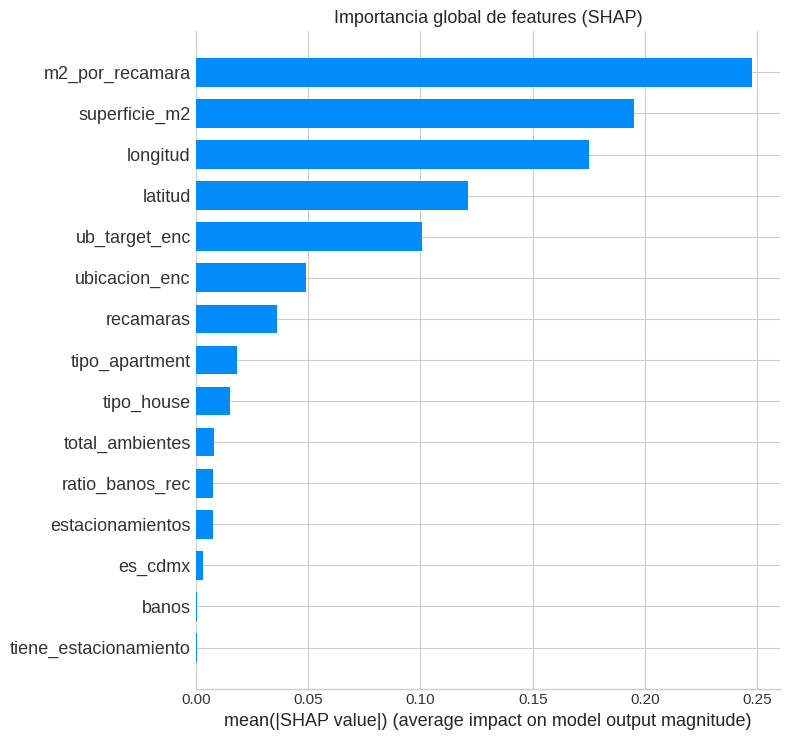

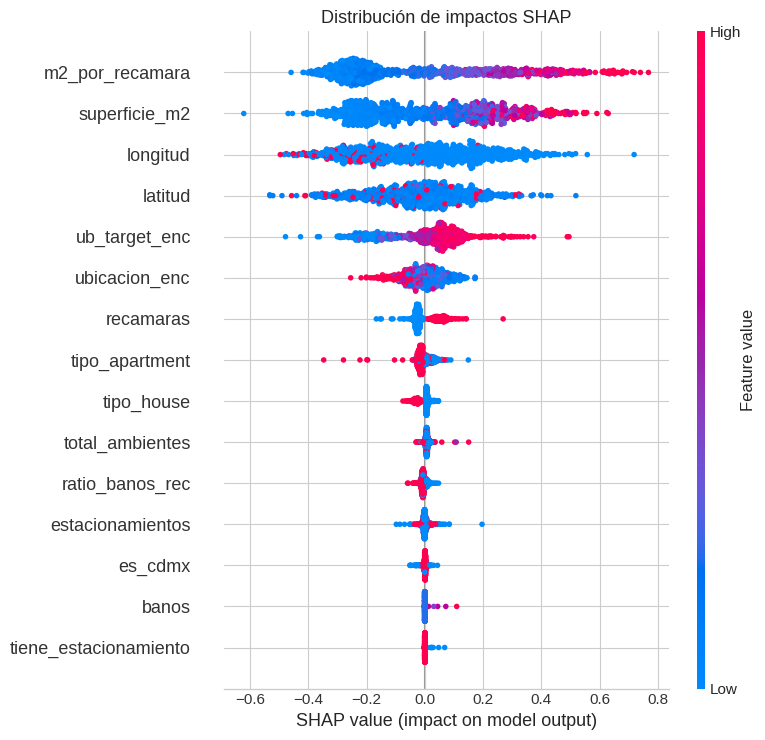

In [50]:
print('Calculando SHAP values...')
explainer = shap.TreeExplainer(best)

# Usar exactamente las mismas columnas con las que se entrenó el modelo
X_shap = X_test_v2[FEAT_V2].sample(min(1000, len(X_test_v2)), random_state=42)
shap_vals = explainer.shap_values(X_shap)
print('✅ Listo')

# Importancia global
shap.summary_plot(shap_vals, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('Importancia global de features (SHAP)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm
shap.summary_plot(shap_vals, X_shap, max_display=15, show=False)
plt.title('Distribución de impactos SHAP', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# **Exportación**

In [51]:
!pip install -q gspread gspread-dataframe

from google.colab import auth
from googleapiclient.discovery import build
import gspread
from gspread_dataframe import set_with_dataframe
import numpy as np

# 1. Autenticación
auth.authenticate_user()
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Preparar df_export — limpiar NaN e inf antes de subir
df_export = df.loc[X_test_v2.index, [
    'ubicacion','superficie_m2','recamaras','banos',
    'estacionamientos','antiguedad','latitud','longitud','precio_mxn']].copy()

df_export = df_export.join(df_raw.loc[df_export.index, 'tipo_inmueble'])

df_export['precio_predicho_mxn'] = y_pred_opt.astype(int)
df_export['error_absoluto_mxn']  = np.abs(y_real.values - y_pred_opt).astype(int)
df_export['error_pct']           = (df_export['error_absoluto_mxn'] / df_export['precio_mxn'] * 100).round(2)
df_export['precio_m2_real']      = (df_export['precio_mxn'] / df_export['superficie_m2']).round(0)
df_export['precio_m2_pred']      = (df_export['precio_predicho_mxn'] / df_export['superficie_m2']).round(0)
df_export['segmento_precio']     = pd.cut(df_export['precio_mxn'],
    bins=[0,1.5e6,3e6,6e6,float('inf')],
    labels=['Económica <1.5M','Media 1.5-3M','Residencial 3-6M','Premium >6M']).astype(str)

# Limpiar NaN, inf y -inf
df_export = df_export.replace([np.inf, -np.inf], np.nan)
df_export = df_export.fillna(0)

# 3. Preparar resumen
resumen = df_export.groupby('ubicacion').agg(
    propiedades=('precio_mxn','count'),
    precio_med_real=('precio_mxn','median'),
    precio_med_pred=('precio_predicho_mxn','median'),
    precio_m2_med=('precio_m2_real','median'),
    error_pct_prom=('error_pct','mean')
).round(2).sort_values('precio_med_real',ascending=False).reset_index()

# 4. Buscar carpeta "Predicción de vivienda" dentro de "LinkedIn Pro IA"
service = build('drive', 'v3', credentials=creds)

# Buscar carpeta padre
query_padre = "name='LinkedIn Pro IA' and mimeType='application/vnd.google-apps.folder' and trashed=false"
padre = service.files().list(q=query_padre, fields='files(id,name)').execute()
padre_id = padre['files'][0]['id'] if padre['files'] else None

# Buscar carpeta hija
if padre_id:
    query_hija = f"name='Predicción de vivienda' and mimeType='application/vnd.google-apps.folder' and '{padre_id}' in parents and trashed=false"
    hija = service.files().list(q=query_hija, fields='files(id,name)').execute()
    folder_id = hija['files'][0]['id'] if hija['files'] else padre_id
    print(f'✅ Carpeta encontrada')
else:
    folder_id = None
    print('⚠️ Carpeta no encontrada — se creará en Mi unidad')

# 5. Crear Spreadsheet
sh = gc.create('Proyecto 02 — Predicción Vivienda México')

# Mover a la carpeta correcta
if folder_id:
    file = service.files().get(fileId=sh.id, fields='parents').execute()
    service.files().update(
        fileId=sh.id,
        addParents=folder_id,
        removeParents=','.join(file.get('parents', [])),
        fields='id,parents'
    ).execute()
    print('✅ Archivo movido a la carpeta correcta')

# 6. Hoja 1: Resultados
ws1 = sh.sheet1
ws1.update_title('Resultados')
set_with_dataframe(ws1, df_export)
print(f'✅ Hoja "Resultados" creada — {len(df_export):,} filas')

# 7. Hoja 2: Resumen por ubicación
ws2 = sh.add_worksheet(title='Resumen por ubicación', rows=100, cols=20)
set_with_dataframe(ws2, resumen)
print(f'✅ Hoja "Resumen por ubicación" creada — {len(resumen)} filas')

# 8. Dar acceso público para Looker Studio
service.permissions().create(
    fileId=sh.id,
    body={'type': 'anyone', 'role': 'reader'}
).execute()

url = f'https://docs.google.com/spreadsheets/d/{sh.id}'
print(f'\n🔗 URL del Sheet: {url}')

✅ Carpeta encontrada
✅ Archivo movido a la carpeta correcta
✅ Hoja "Resultados" creada — 3,334 filas
✅ Hoja "Resumen por ubicación" creada — 28 filas

🔗 URL del Sheet: https://docs.google.com/spreadsheets/d/1taoAGheCsHC4VulxSOSpMo6x3WTiOw5gcIXMhInpxAc

Próximo paso → Looker Studio → Crear → Fuente de datos → Google Sheets → pega la URL
